# Unbalanced OT and KL Mass Relaxation

This notebook generates `fig:unbalanced-mass-relaxation`.  It solves a one-dimensional unbalanced entropic OT problem between two Gaussian-mixture densities,
$$
\min_{P\ge 0}\; \langle C,P\rangle
+\varepsilon\,\mathrm{KL}(P\mid a\otimes b)
+\tau\,\mathrm{KL}(P\mathbf 1\mid a)
+\tau\,\mathrm{KL}(P^\top\mathbf 1\mid b).
$$
The parameter $\tau$ controls the price of marginal mismatch: small $\tau$ makes creation and destruction cheap, while large $\tau$ forces the transported marginals toward the prescribed red and blue densities.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from matplotlib.colors import LinearSegmentedColormap

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    GRAY,
    AXIS_LINE_WIDTH,
    figure_dir,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "unbalanced-mass-relaxation"
OUT = figure_dir(NAME)


## Gaussian-mixture marginals

The source density $\alpha$ has two modes.  The target density $\beta$ has two nearby modes and one far right mode.  For small $\tau$, it is cheaper to destroy some source mass and create the far target mass than to transport mass over the long distance.  For large $\tau$, the plan is forced to explain almost all of both marginals.

In [2]:
def gaussian(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi))


grid = np.linspace(-3.0, 3.0, 150)
dx = grid[1] - grid[0]

alpha_density = 0.62 * gaussian(grid, -1.35, 0.30) + 0.38 * gaussian(grid, 0.35, 0.23)
beta_density = (
    0.30 * gaussian(grid, -0.80, 0.28)
    + 0.42 * gaussian(grid, 0.85, 0.32)
    + 0.28 * gaussian(grid, 2.20, 0.20)
)

alpha = alpha_density * dx
beta = beta_density * dx
cost = (grid[:, None] - grid[None, :]) ** 2
cost = cost / np.median(cost)

EPSILON = 0.02
TAU_VALUES = [0.04, 0.25, 20.0]
TAU_FILENAMES = ["tau-small.pdf", "tau-medium.pdf", "tau-large.pdf"]

plans = [
    ot.unbalanced.sinkhorn_unbalanced(
        alpha,
        beta,
        cost,
        reg=EPSILON,
        reg_m=tau,
        numItermax=4000,
        stopThr=1e-10,
        warn=False,
    )
    for tau in TAU_VALUES
]


## Coupling with side marginals

Each panel contains a coupling density matrix.  The left side plot compares the prescribed source density $\alpha$ in red with the transported source marginal $P\mathbf 1$ in violet; the red gap is destroyed mass.  The top side plot compares the prescribed target density $\beta$ in blue with the transported target marginal $P^\top\mathbf 1$ in violet; the blue gap is created mass.

In [3]:
plan_cmap = LinearSegmentedColormap.from_list(
    "unbalanced_plan",
    ["#ffffff", "#f2e7f3", "#c9a3d5", VIOLET],
)

all_row_densities = [P.sum(axis=1) / dx for P in plans]
all_col_densities = [P.sum(axis=0) / dx for P in plans]
side_scale = 1.05 * max(
    alpha_density.max(),
    beta_density.max(),
    max(row.max() for row in all_row_densities),
    max(col.max() for col in all_col_densities),
)
plan_scale = max(np.sqrt((P / dx**2).max()) for P in plans)


def remove_side_axes(ax):
    remove_axes(ax)
    ax.set_facecolor("white")


def box_matrix_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(AXIS_LINE_WIDTH)
        spine.set_edgecolor("#333333")


def draw_panel(P, filename):
    row_density = P.sum(axis=1) / dx
    col_density = P.sum(axis=0) / dx
    plan_density = np.sqrt(P / dx**2) / max(plan_scale, 1e-15)

    fig = plt.figure(figsize=(2.55, 2.35))
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[0.30, 1.0],
        height_ratios=[0.30, 1.0],
        wspace=0.035,
        hspace=0.035,
    )
    ax_corner = fig.add_subplot(gs[0, 0])
    ax_top = fig.add_subplot(gs[0, 1])
    ax_left = fig.add_subplot(gs[1, 0])
    ax_matrix = fig.add_subplot(gs[1, 1])

    remove_side_axes(ax_corner)

    ax_top.fill_between(grid, col_density, beta_density, where=beta_density >= col_density, color=BLUE, alpha=0.18, linewidth=0)
    ax_top.fill_between(grid, 0, col_density, color=VIOLET, alpha=0.30, linewidth=0)
    ax_top.plot(grid, beta_density, color=BLUE, lw=0.85)
    ax_top.plot(grid, col_density, color=VIOLET, lw=0.8)
    ax_top.set_xlim(grid[0], grid[-1])
    ax_top.set_ylim(0, side_scale)
    remove_side_axes(ax_top)

    ax_left.fill_betweenx(grid, row_density, alpha_density, where=alpha_density >= row_density, color=RED, alpha=0.18, linewidth=0)
    ax_left.fill_betweenx(grid, 0, row_density, color=VIOLET, alpha=0.30, linewidth=0)
    ax_left.plot(alpha_density, grid, color=RED, lw=0.85)
    ax_left.plot(row_density, grid, color=VIOLET, lw=0.8)
    ax_left.set_ylim(grid[0], grid[-1])
    ax_left.set_xlim(side_scale, 0)
    remove_side_axes(ax_left)

    ax_matrix.imshow(
        plan_density,
        extent=[grid[0], grid[-1], grid[0], grid[-1]],
        origin="lower",
        cmap=plan_cmap,
        vmin=0,
        vmax=1,
        interpolation="nearest",
        aspect="auto",
    )
    ax_matrix.set_xlim(grid[0], grid[-1])
    ax_matrix.set_ylim(grid[0], grid[-1])
    box_matrix_axis(ax_matrix)

    save_pdf(fig, OUT / filename, pad_inches=0.055)
    plt.close(fig)


for P, filename in zip(plans, TAU_FILENAMES):
    draw_panel(P, filename)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


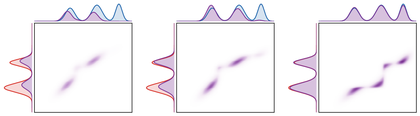

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/unbalanced-mass-relaxation.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/unbalanced-mass-relaxation.png")
display(Image(filename=str(_thumb)))
